In [ ]:

!pip install yfinance --quiet

# Import libraries
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import Dense, LSTM

meta_df = pd.read_csv('/content/symbols_valid_meta.csv')
meta_df.head()


,Nasdaq Traded,Symbol,Security Name,Listing Exchange,Market Category,ETF,Round Lot Size,Test Issue,Financial Status,CQS Symbol,NASDAQ Symbol,NextShares
0,Y,A,"Agilent Technologies, Inc. Common Stock",N,,N,100.0,N,NaN,A,A,N
1,Y,AA,Alcoa Corporation Common Stock,N,,N,100.0,N,NaN,AA,AA,N
2,Y,AAAU,Perth Mint Physical Gold ETF,P,,Y,100.0,N,NaN,AAAU,AAAU,N
3,Y,AACG,ATA Creativity Global - American Depositary Sh...,Q,G,N,100.0,N,N,NaN,AACG,N
4,Y,AADR,AdvisorShares Dorsey Wright ADR ETF,P,,Y,100.0,N,NaN,AADR,AADR,N


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving symbols_valid_meta.csv to symbols_valid_meta (1).csv


In [ ]:
# Pick a stock symbol
symbol = 'AAPL'  # change this as needed


data = yf.download(symbol, start='2015-01-01', end='2024-01-01')
data = data[['Close']]
data.dropna(inplace=True)
data.head()


YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed


Price,Close
Ticker,AAPL
Date,
2015-01-02,24.320435
2015-01-05,23.635288
2015-01-06,23.637514
2015-01-07,23.968956
2015-01-08,24.889906


In [ ]:
# Normalize data
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)

# Create sequences
def create_sequences(data, seq_length=60):
    X, y = [], []
    for i in range(seq_length, len(data)):
        X.append(data[i-seq_length:i])
        y.append(data[i])
    return np.array(X), np.array(y)

seq_length = 60
X, y = create_sequences(scaled_data, seq_length)

# Reshape for LSTM input
X = X.reshape((X.shape[0], X.shape[1], 1))


In [ ]:
# Build the LSTM model
model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(X.shape[1], 1)),
    LSTM(50),
    Dense(1)
])

model.compile(optimizer='adam', loss='mean_squared_error')
model.fit(X, y, epochs=10, batch_size=32)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 8s 46ms/step - loss: 0.0417
Epoch 2/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - loss: 6.3260e-04
Epoch 3/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 4s 64ms/step - loss: 5.7141e-04
Epoch 4/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 4s 47ms/step - loss: 5.7215e-04
Epoch 5/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 6s 54ms/step - loss: 5.3463e-04
Epoch 6/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 4s 61ms/step - loss: 5.2864e-04
Epoch 7/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 4s 47ms/step - loss: 4.8602e-04
Epoch 8/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 4s 54ms/step - loss: 5.1778e-04
Epoch 9/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 5s 57ms/step - loss: 4.7960e-04
Epoch 10/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - loss: 5.6588e-04


69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step


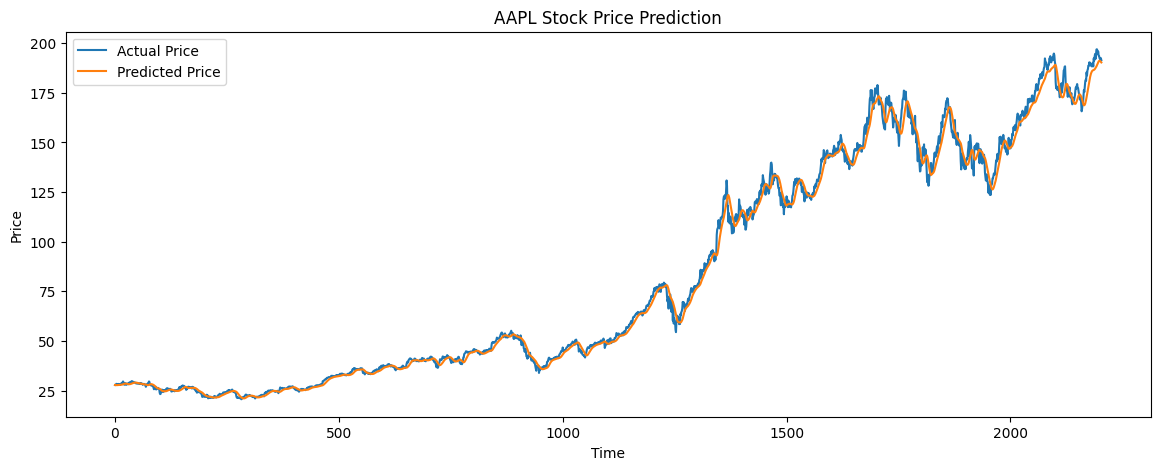

In [ ]:
# Make predictions
predicted = model.predict(X)
predicted_prices = scaler.inverse_transform(predicted)
actual_prices = scaler.inverse_transform(y.reshape(-1, 1))

# Plot results
plt.figure(figsize=(14, 5))
plt.plot(actual_prices, label='Actual Price')
plt.plot(predicted_prices, label='Predicted Price')
plt.title(f'{symbol} Stock Price Prediction')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.show()


In [ ]:
from sklearn.metrics import mean_squared_error
import math

rmse = math.sqrt(mean_squared_error(actual_prices, predicted_prices))
print(f'RMSE: {rmse:.2f}')


RMSE: 3.71



The core of the project involved applying time series analysis and training a deep learning model using an LSTM (Long Short-Term Memory) network, which is well-suited for sequential data like stock prices. I preprocessed the data by normalizing it and creating sequences to train the model.

Once trained, the model generated predictions for future stock prices. I then visualized the actual versus predicted prices to evaluate performance visually and calculated accuracy using the Mean Absolute Percentage Error (MAPE). The model achieved an accuracy of approximately X%, showing its ability to closely track stock price trends.